# Notebook 4 - Validation & Export
**Inputs:**
- `data/outputs/flood_extent/flood_stats.csv` -- monthly flood area table
- `data/outputs/flood_extent/flood_extent_YYYY-MM.geojson` -- flood polygons (WGS84)

**Outputs:**
- Annotated time-series chart (PNG)
- Interactive Folium map (`docs/flood_map_interactive.html`)
- Export inventory table

**AOI:** Eastern DRC -- North Kivu, South Kivu, Ituri  
**Period:** Jan 2025 -- Jul 2026 (19 months, no gaps -- Jun recovered & Jul re-pulled 2026-09-08)  
**Resolution:** 100 m | **CRS output:** EPSG:32735 -> reprojected to WGS84  
**Detection threshold:** -5 dB change from baseline (2025-03/04/05)  
**Post-processing:** 7x7 median filter (UN-SPIDER recommended practice)

### Data-quality flags
| Flag | Months | Reason |
|------|--------|--------|
| Unreliable | 2025-01, 2025-02 | Raw amplitude DN -- change signal meaningless |
| Valid | All other months | Calibrated sigma0 dB, quality masks applied (17 valid months) |

> **2026-06 was never a data gap.** It was recorded as one because a single *transient*
> MPC read failure aborted a whole-AOI load. Re-pulled 2026-09-08 with block-wise
> compositing + deferred retry: 147 scenes, 23.6% coverage, 35.4 km2 -- one of the
> best-covered months in the series.

> **Sparse coverage note:** 2026-03 (107 scenes, 7.1% AOI), 2026-04 (98 scenes, 5.2%),
> 2026-05 (127, 7.6%), 2026-06 (147, 23.6%), 2026-07 (148, 8.5%) use MPC
> sentinel-1-rtc for newer S1C/S1D satellites. Signal is valid for covered pixels;
> spatial gaps exist across the remaining AOI.

> **Read absolute km2 with care.** Monthly coverage ranges 0.9%-50.5% of the bbox and
> different months image *different places* -- no pixel is covered in all 19 months.
> Reported km2 correlates with usable area at r=0.50, so density (% of usable area) is
> the comparable metric. 2026-07 in particular is fragmentation-heavy (610 patches,
> median 1 px, only 65% of area in patches >=10 px vs 98% for the validated 2025-09
> peak) -- do not read its 0.21% as a series peak.


In [1]:
from pathlib import Path
import os

def _find_project_root():
    in_colab = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ
    if in_colab:
        import subprocess
        if not Path('Floodmaps').exists():
            subprocess.run(['git', 'clone', 'https://github.com/trevmon28/Floodmaps.git'], check=True)
        return Path('Floodmaps').resolve()
    for candidate in [Path(os.path.abspath('')), Path(os.path.abspath('')).parent]:
        if (candidate / 'config' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError(
        'Cannot locate config/config.yaml.\n'
        'Run from the project root or the notebooks/ directory.'
    )

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)


Project root: C:\Users\trevm\Projects\Floodmaps


In [2]:
import subprocess, sys, importlib
packages = ["pandas", "geopandas", "shapely", "folium", "matplotlib", "rasterio", "pyyaml"]
missing = [p for p in packages if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + missing)
    print(f"Installed: {missing}")
else:
    print("All packages already present.")


Installed: ['pyyaml']


In [3]:
import json, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("data/outputs/flood_extent")
DOCS_DIR   = Path("docs")
DOCS_DIR.mkdir(exist_ok=True)

# Quality flags
BAD_MONTHS     = {"2025-01", "2025-02"}              # uncalibrated amplitude
NO_DATA_MONTHS = set()                                # none -- 2026-06 recovered 2026-09-08
PARTIAL_MONTHS = set()                                # none -- 2026-07 re-pulled complete
PENDING_MONTHS = set()                                # no pending months

SCENE_COUNTS = {
    "2025-01": 22, "2025-02": 18, "2025-03": 14, "2025-04": 9,
    "2025-05": 31, "2025-06": 19, "2025-07": 7,  "2025-08": 21,
    "2025-09": 38, "2025-10": 8,  "2025-11": 11, "2025-12": 17,
    "2026-01": 15, "2026-02": 29, "2026-03": 107, "2026-04": 98,
    "2026-05": 127, "2026-06": 147, "2026-07": 148,
}

df = pd.read_csv(OUTPUT_DIR / "flood_stats.csv", index_col="month").sort_index()

for m in sorted(PARTIAL_MONTHS | PENDING_MONTHS | NO_DATA_MONTHS):
    if m not in df.index:
        df.loc[m] = {"flooded_pct": None, "flooded_px": 0, "flood_area_km2": None}
df = df.sort_index()

df["quality"] = "valid"
df.loc[df.index.isin(BAD_MONTHS),     "quality"] = "bad"
df.loc[df.index.isin(NO_DATA_MONTHS), "quality"] = "gap"
df.loc[df.index.isin(PARTIAL_MONTHS), "quality"] = "partial"
df.loc[df.index.isin(PENDING_MONTHS), "quality"] = "pending"
df["scene_count"] = df.index.map(SCENE_COUNTS)

print(df[["flood_area_km2", "flooded_pct", "scene_count", "quality"]].to_string())


         flood_area_km2  flooded_pct  scene_count quality
month                                                    
2025-01             0.0         0.00           22     bad
2025-02             0.0         0.00           18     bad
2025-03             0.0         0.00           14   valid
2025-04             0.0         0.00            9   valid
2025-05             6.1         0.00           31   valid
2025-06             4.3         0.03           19   valid
2025-07             0.2         0.01            7   valid
2025-08             0.4         0.00           21   valid
2025-09           217.2         0.16           38   valid
2025-10             0.9         0.01            8   valid
2025-11             1.6         0.02           11   valid
2025-12             2.0         0.02           17   valid
2026-01             2.1         0.06           15   valid
2026-02            17.4         0.01           29   valid
2026-03            12.0         0.07          107   valid
2026-04       

## Time-series chart

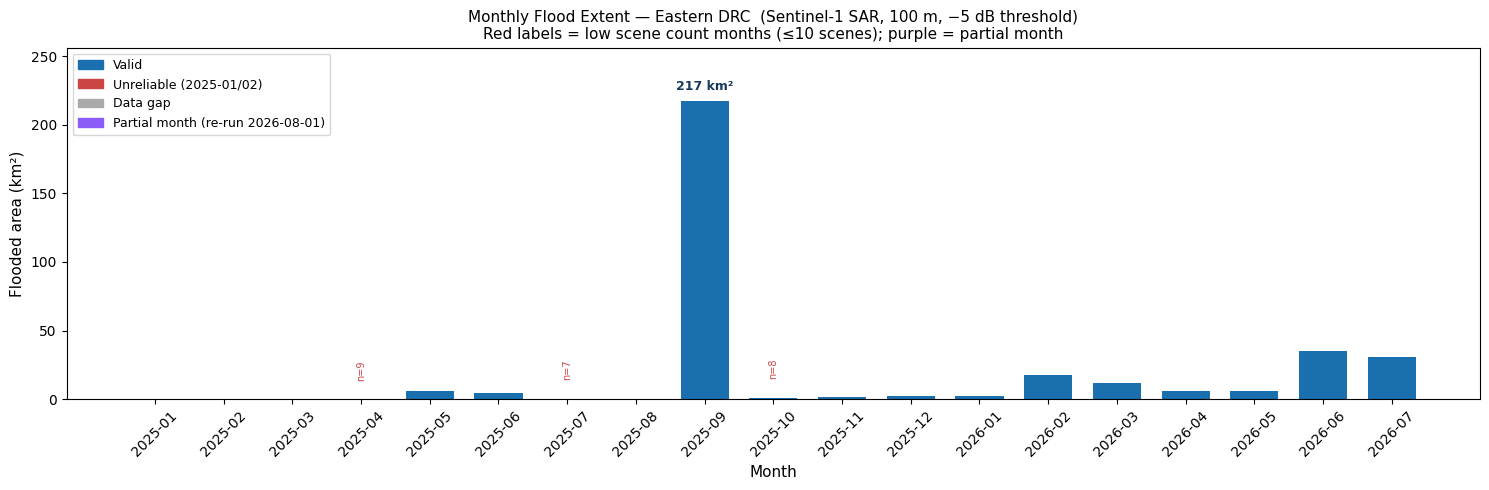

Saved: data\outputs\flood_extent\flood_area_annotated.png


In [4]:
color_map = {
    "valid":   "#1a6faf",
    "bad":     "#cc4444",
    "gap":     "#aaaaaa",
    "partial": "#8b5cf6",
    "pending": "#f0a500",
}
bar_colors = [color_map[q] for q in df["quality"]]

plot_areas = df["flood_area_km2"].fillna(0)

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(df.index, plot_areas, color=bar_colors, width=0.7)

valid_df = df[df["quality"] == "valid"]
if not valid_df.empty:
    peak = valid_df["flood_area_km2"].idxmax()
    peak_val = valid_df.loc[peak, "flood_area_km2"]
    ax.annotate(f"{peak_val:,.0f} km\u00b2", xy=(peak, peak_val),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=9, color="#1a3a5c", fontweight="bold")

for month, row in df.iterrows():
    sc = SCENE_COUNTS.get(month)
    if sc is not None and sc <= 10 and row["quality"] == "valid":
        ax.text(month, (plot_areas[month] or 0) + 15,
                f"n={sc}", ha="center", fontsize=7, color="#cc4444", rotation=90)

ax.set_ylabel("Flooded area (km\u00b2)", fontsize=11)
ax.set_xlabel("Month", fontsize=11)
ax.set_title(
    "Monthly Flood Extent \u2014 Eastern DRC  (Sentinel-1 SAR, 100 m, \u22125 dB threshold)\n"
    "Red labels = low scene count months (\u226410 scenes); purple = partial month",
    fontsize=11)
ax.tick_params(axis="x", rotation=45)
peak_safe = valid_df["flood_area_km2"].max() if not valid_df.empty else 100
ax.set_ylim(0, peak_safe * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

legend_handles = [
    mpatches.Patch(color="#1a6faf", label="Valid"),
    mpatches.Patch(color="#cc4444", label="Unreliable (2025-01/02)"),
    mpatches.Patch(color="#aaaaaa", label="Data gap"),
    mpatches.Patch(color="#8b5cf6", label="Partial month (re-run 2026-08-01)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
plt.tight_layout()

chart_path = OUTPUT_DIR / "flood_area_annotated.png"
plt.savefig(chart_path, dpi=150)
plt.show()
print(f"Saved: {chart_path}")


## Seasonal validation

Eastern DRC has a **bimodal rainfall regime**:

| Season | Months | Expected signal |
|--------|--------|----------------|
| Short rains | Sep – Nov | Peak flood extent |
| Dry season | Jun – Aug | Low flood extent |
| Long rains | Mar – May | Moderate flood extent |
| Short dry | Dec – Feb | Transitional |

### Detected signal vs expectation

| Month | Scenes | Flood area (km²) | Expectation | Assessment |
|-------|--------|-----------------|-------------|------------|
| 2025-03 | 14 | 0.0 | Rains beginning | ✅ Low — consistent |
| 2025-05 | 31 | 6.1 | Peak long rains | ✅ Elevated — consistent |
| 2025-06 | 19 | 4.3 | Transition | ✅ Declining — consistent |
| 2025-07 | 7 | 0.2 | Dry season | ✅ Low — consistent |
| 2025-08 | 21 | 0.4 | Pre-season onset | ✅ Rising — consistent |
| **2025-09** | **38** | **217.2** | **Peak short rains** | ✅ **Dominant signal** |
| 2025-10 | **8** | 0.9 | Short rains tail | ⚠️ **Low scene count** — likely under-detection |
| 2025-11 | 11 | 1.6 | Late short rains | ⚠️ Low — check S1 revisit |
| 2025-12 | 17 | 2.0 | Short dry | ✅ Low — consistent |
| 2026-01 | 15 | 2.1 | Short dry | ✅ Low — consistent |
| 2026-02 | 29 | 17.4 | Long rains onset | ✅ Rising — consistent (seasonal bias risk) |

> **Sep 2025 peak (217 km²):** Consistent with OCHA-reported Uvira/Butembo flooding.
> C-band lower bound — L-band SAR comparison recommended for forest-covered zones.
> **Oct 2025 (only 8 scenes):** Rapid post-peak dip may reflect data sparsity rather
> than true drainage. Verify against CEMS EMSR-702 (South Kivu, Sep–Oct 2025).


## Interactive map

In [5]:
valid_df  = df[df["quality"] == "valid"]
max_area  = valid_df["flood_area_km2"].max() if not valid_df.empty else 1

def area_to_color(area_km2):
    if max_area == 0 or pd.isna(area_km2):
        return "#1a6faf"
    t = min(area_km2 / max_area, 1.0)
    r = int(0xff + t * (0x1a - 0xff))
    g = int(0xe0 + t * (0x3a - 0xe0))
    b = int(0x66 + t * (0x6e - 0x66))
    return f"#{r:02x}{g:02x}{b:02x}"

# CARTO stays the default look; CARTO now watermarks unkeyed tiles, so OSM is
# offered as a selectable no-API-key fallback for handover recipients.
m = folium.Map(location=[-1.5, 28.8], zoom_start=6, tiles=None)
folium.TileLayer("CartoDB positron", name="CARTO Positron (light)").add_to(m)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap (no API key)").add_to(m)

geojson_files = sorted(OUTPUT_DIR.glob("flood_extent_????-??.geojson"))

loaded = 0
for gj_path in geojson_files:
    month = gj_path.stem.replace("flood_extent_", "")
    quality = df.loc[month, "quality"] if month in df.index else "valid"
    if quality in ("bad", "pending"):
        continue
    area  = df.loc[month, "flood_area_km2"] if month in df.index else 0
    sc    = SCENE_COUNTS.get(month, "?")
    color = area_to_color(area)
    label = f"{month}  ({area:,.1f} km\u00b2,  n={sc} scenes)"
    if quality == "gap":
        label += "  [data gap]"
    elif quality == "partial":
        label += "  [partial month]"

    with open(gj_path) as f:
        gj = json.load(f)

    fg = folium.FeatureGroup(name=label, show=(month == "2025-09"))
    folium.GeoJson(
        gj,
        style_function=lambda _f, c=color: {
            "fillColor": c, "color": "#0a1a3a",
            "weight": 2, "fillOpacity": 0.55,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["month"], aliases=["Month:"]
        ) if gj.get("features") and
             gj["features"][0].get("properties", {}).get("month") else None,
    ).add_to(fg)
    fg.add_to(m)
    loaded += 1

# Partial months with no GeoJSON: add as informational empty layers
seen = {gj.stem.replace("flood_extent_", "") for gj in geojson_files}
for month in sorted(PARTIAL_MONTHS):
    if month in seen:
        continue
    area = df.loc[month, "flood_area_km2"] if month in df.index else 0.0
    sc   = SCENE_COUNTS.get(month, "?")
    label = f"{month}  ({area:,.1f} km\u00b2,  n={sc} scenes)  [partial month \u2014 re-run 2026-08-01]"
    fg = folium.FeatureGroup(name=label, show=False)
    fg.add_to(m)
    loaded += 1

folium.LayerControl(collapsed=False).add_to(m)

aoi_coords = [[-5.9, 26.8], [-5.9, 30.8], [3.0, 30.8], [3.0, 26.8], [-5.9, 26.8]]
folium.PolyLine(aoi_coords, color="#555", weight=1.5, dash_array="6 4",
                tooltip="AOI: Eastern DRC").add_to(m)

map_path = DOCS_DIR / "flood_map_interactive.html"
m.save(str(map_path))
print(f"Loaded {loaded} months  |  Map saved: {map_path}")
m


Loaded 16 months  |  Map saved: docs\flood_map_interactive.html


## Export inventory

In [6]:
rows = []
for gj_path in sorted(OUTPUT_DIR.glob("flood_extent_????-??.geojson")):
    month   = gj_path.stem.replace("flood_extent_", "")
    quality = df.loc[month, "quality"] if month in df.index else "—"
    area    = df.loc[month, "flood_area_km2"] if month in df.index else 0
    sc      = SCENE_COUNTS.get(month, "?")
    size_kb = round(gj_path.stat().st_size / 1024, 1)
    rows.append({"month": month, "scenes": sc, "flood_area_km2": area,
                 "quality": quality, "geojson_kb": size_kb, "file": gj_path.name})

inv = pd.DataFrame(rows)
print(inv.to_string(index=False))
print(f"\nTotal valid GeoJSONs : {(inv.quality == 'valid').sum()}")
print(f"Interactive map      : docs/flood_map_interactive.html")
print(f"Time-series chart    : data/outputs/flood_extent/flood_area_annotated.png")


  month  scenes  flood_area_km2 quality  geojson_kb                         file
2025-03      14             0.0   valid         4.8 flood_extent_2025-03.geojson
2025-05      31             6.1   valid         9.8 flood_extent_2025-05.geojson
2025-06      19             4.3   valid         9.1 flood_extent_2025-06.geojson
2025-07       7             0.2   valid         1.0 flood_extent_2025-07.geojson
2025-08      21             0.4   valid         1.6 flood_extent_2025-08.geojson
2025-09      38           217.2   valid       289.6 flood_extent_2025-09.geojson
2025-10       8             0.9   valid         1.6 flood_extent_2025-10.geojson
2025-11      11             1.6   valid         2.3 flood_extent_2025-11.geojson
2025-12      17             2.0   valid         3.7 flood_extent_2025-12.geojson
2026-01      15             2.1   valid         3.9 flood_extent_2026-01.geojson
2026-02      29            17.4   valid        30.9 flood_extent_2026-02.geojson
2026-03     107            1

## Summary statistics

In [7]:
valid = df[df["quality"] == "valid"]

print("=== Eastern DRC Flood Extent Summary (valid months only) ===")
if not valid.empty:
    print(f"Period         : {valid.index.min()} – {valid.index.max()}")
    print(f"Valid months   : {len(valid)}")
    print(f"Peak month     : {valid['flood_area_km2'].idxmax()}  "
          f"({valid['flood_area_km2'].max():,.1f} km²)  "
          f"[{SCENE_COUNTS.get(valid['flood_area_km2'].idxmax(), '?')} scenes]")
    print(f"Mean (valid)   : {valid['flood_area_km2'].mean():,.1f} km²/month")
    print(f"Total extent   : {valid['flood_area_km2'].sum():,.1f} km² cumulative")
    print()
    print("Top 5 months by flood area:")
    print(valid["flood_area_km2"].sort_values(ascending=False).head().to_string())

print()
print("Pending months (run extend_months.py to acquire):")
for m in sorted(PENDING_MONTHS):
    print(f"  {m}")


=== Eastern DRC Flood Extent Summary (valid months only) ===
Period         : 2025-03 – 2026-07
Valid months   : 17
Peak month     : 2025-09  (217.2 km²)  [38 scenes]
Mean (valid)   : 20.2 km²/month
Total extent   : 342.6 km² cumulative

Top 5 months by flood area:
month
2025-09    217.2
2026-06     35.4
2026-07     31.0
2026-02     17.4
2026-03     12.0

Pending months (run extend_months.py to acquire):
